In [1]:
import geopandas as gpd
import xarray as xr
import numpy as np
from scipy.spatial import cKDTree
from pyproj import Transformer
import matplotlib.pyplot as plt

In [2]:
### Efficient forest distance with cKDTree ###
thailandmap = gpd.read_file('Data\\tha_admbnda_adm1_rtsd_20220121\\tha_admbnda_adm1_rtsd_20220121.shp').to_crs(epsg=4326)
min_lon, min_lat, max_lon, max_lat = thailandmap.total_bounds

xr_landuse = xr.open_dataset("Data//dataset-satellite-land-cover//C3S-LC-L4-LCCS-Map-300m-P1Y-2022-v2.1.1.nc")
lat_vals = xr_landuse['lat']
lon_vals = xr_landuse['lon']
if lat_vals[0] > lat_vals[-1]:
    lat_slice = slice(max_lat, min_lat)
else:
    lat_slice = slice(min_lat, max_lat)
if lon_vals[0] > lon_vals[-1]:
    lon_slice = slice(max_lon, min_lon)
else:
    lon_slice = slice(min_lon, max_lon)

xr_landuse = xr_landuse.sel(lat=lat_slice, lon=lon_slice)
xr_landuse = xr_landuse.reindex(lat=xr_landuse.lat[::-1])
xr_landuse = xr_landuse.sel(time='2022-01-01').drop_vars('time')
lccs_resolution = 300  # meters

forest_codes = [50,60,61,62,70,71,72,80,81,82,90,100,160,170]
xr_landuse = xr_landuse.assign(forest=xr.where(xr_landuse['lccs_class'].isin(forest_codes), 1, 0))

lons = xr_landuse['lon'].values
lats = xr_landuse['lat'].values
lon2d, lat2d = np.meshgrid(lons, lats)

transformer = Transformer.from_crs('epsg:4326', 'epsg:3857', always_xy=True)
x2d, y2d = transformer.transform(lon2d, lat2d)

forest_mask = xr_landuse['forest'].values.astype(bool)
print('forest mask candidate points:', np.count_nonzero(forest_mask), 'of', forest_mask.size)
forest_x = x2d[forest_mask]
forest_y = y2d[forest_mask]

# skip explicit boundary filter because xr_landuse area already clipped by Thailand bounds
# thailand_union_3857 = thailandmap.to_crs(epsg=3857).union_all()
# (optional) check inside boundary if needed
# if forest_inside is required, use shapely.vectorized.contains or Point checks

if forest_x.size == 0:
    raise ValueError('No forest points found in forest mask')

forest_tree = cKDTree(np.column_stack([forest_x, forest_y]))
query_pts = np.column_stack([x2d.ravel(), y2d.ravel()])
dist_flat, _ = forest_tree.query(query_pts, k=1)
dist2d = dist_flat.reshape(x2d.shape)

# Zero distance for forest pixels themselves
forest_idx_flat = np.flatnonzero(forest_mask.ravel())
dist2d.ravel()[forest_idx_flat] = 0

xr_distancetoforest = xr.Dataset(
    {'distance': (('lat', 'lon'), dist2d)},
    coords={'lat': lats, 'lon': lons}
)

print(xr_distancetoforest)

forest mask candidate points: 3578731 of 15957810
<xarray.Dataset> Size: 128MB
Dimensions:   (lat: 5346, lon: 2985)
Coordinates:
  * lat       (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon       (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance  (lat, lon) float64 128MB 2.259e+05 2.257e+05 2.254e+05 ... 0.0 0.0


In [3]:
# Vectorized SI assignment with landcover mask
xr_landuse_suitability_index = xr.open_dataset('Output\\xr_SI_Landcover.nc').sel(lat=xr_distancetoforest.lat, lon=xr_distancetoforest.lon)

xr_distancetoforest['SI_Wind'] = xr.where(xr_distancetoforest.distance < (1500 + lccs_resolution), 0, 3)
xr_distancetoforest['SI_Solar'] = xr.where(xr_distancetoforest.distance < (1000 + lccs_resolution), 0, 3)

xr_distancetoforest['SI_Wind'] = xr.where(xr_landuse_suitability_index['SI_Wind'] == 0, 0, xr_distancetoforest['SI_Wind'])
xr_distancetoforest['SI_Solar'] = xr.where(xr_landuse_suitability_index['SI_Solar'] == 0, 0, xr_distancetoforest['SI_Solar'])

print(xr_distancetoforest)

<xarray.Dataset> Size: 255MB
Dimensions:   (lat: 5346, lon: 2985)
Coordinates:
  * lat       (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon       (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance  (lat, lon) float64 128MB 2.259e+05 2.257e+05 2.254e+05 ... 0.0 0.0
    SI_Wind   (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    SI_Solar  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0


In [4]:
# Save optimized dataset directly
output_path = 'Output\\xr_SI_Distancetoforest.nc'
xr_distancetoforest.to_netcdf(path=output_path)
print('Saved', output_path)
print(xr_distancetoforest)

Saved Output\xr_SI_Distancetoforest.nc
<xarray.Dataset> Size: 255MB
Dimensions:   (lat: 5346, lon: 2985)
Coordinates:
  * lat       (lat) float64 43kB 5.615 5.618 5.621 5.624 ... 20.46 20.46 20.46
  * lon       (lon) float64 24kB 97.35 97.35 97.35 97.35 ... 105.6 105.6 105.6
Data variables:
    distance  (lat, lon) float64 128MB 2.259e+05 2.257e+05 2.254e+05 ... 0.0 0.0
    SI_Wind   (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    SI_Solar  (lat, lon) int32 64MB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0


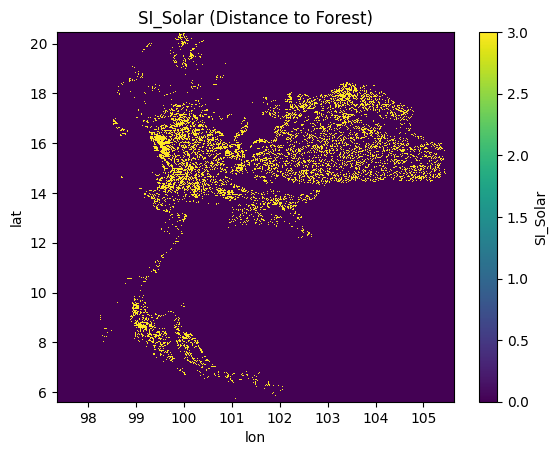

In [5]:
plot_obj = xr_distancetoforest['SI_Solar'].plot(cmap='viridis')
plt.title('SI_Solar (Distance to Forest)')
plt.show()

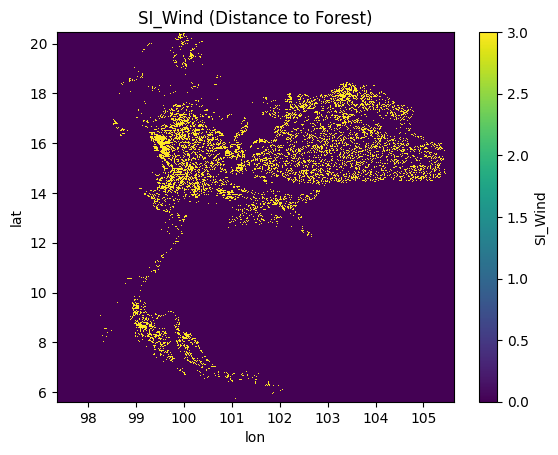

In [6]:
plot_obj = xr_distancetoforest['SI_Wind'].plot(cmap='viridis')
plt.title('SI_Wind (Distance to Forest)')
plt.show()